# Reverse diffusion on $S^2$

Constructing an initial smiley face shaped distribution on $S^2$ and generating points from it using reverse diffusion and the exact score. Later, training a neural net to learn the score and reproduce the initial distribution.

In [102]:
#Run initializing code containing globals and function definitions

%run smiley.py

## Constructing and diffusing target distribution

### Sample points from initial distribution

In [ ]:
samples0 = generateInitial(10000) #deprecated function
plotSphereHist(samples0)

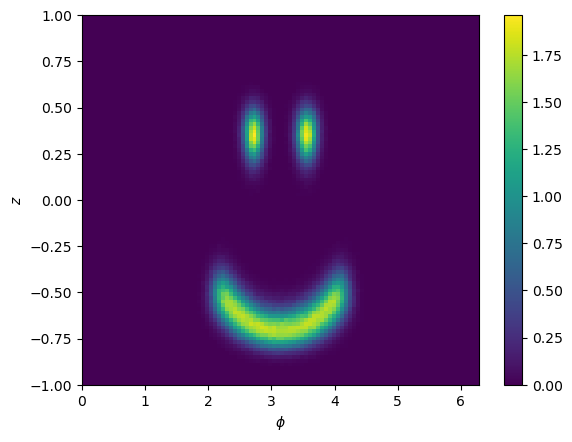

In [4]:
samples0 = smileySample(8*nSmile*10000)
plotSphereHist(samples0)

### Diffusing distribution

Calculate both the diffused distribution and the diffused samples and compare. Demonstrate that the distribution is close to uniform at $t=4$ with total variation (TV) distance $2\times 10^{-4}$.

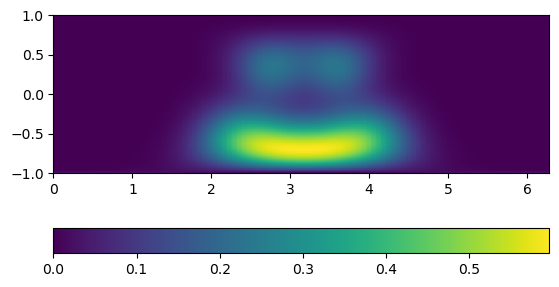

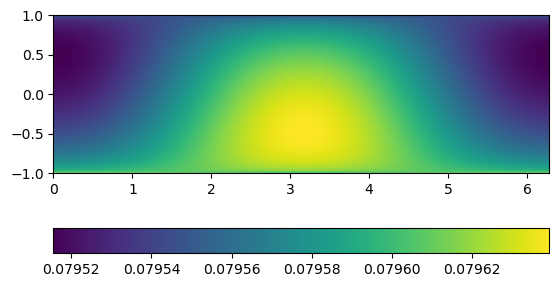

In [5]:
plotSphereDist(lambda x: smileyDist(x, .04))
plotSphereDist(lambda x: smileyDist(x, 4))

Diffuse samples over a range of times

In [6]:
# times to diffuse

timesU = np.linspace(0,1,5)
print(timesU)
timesTau = sde.tauFromU(timesU,t0,tF)
print(timesTau)

[0.   0.25 0.5  0.75 1.  ]
[0.         0.02159979 0.13650972 0.74782562 4.        ]


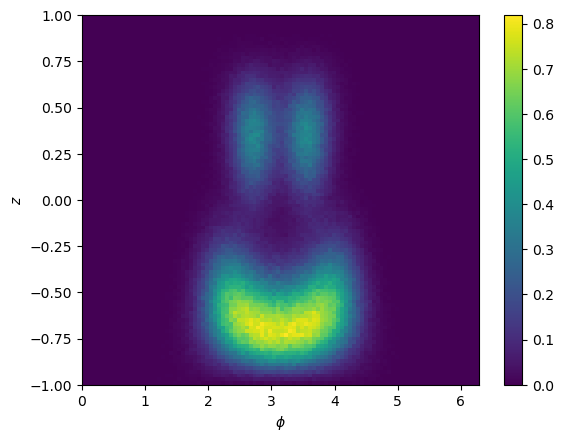

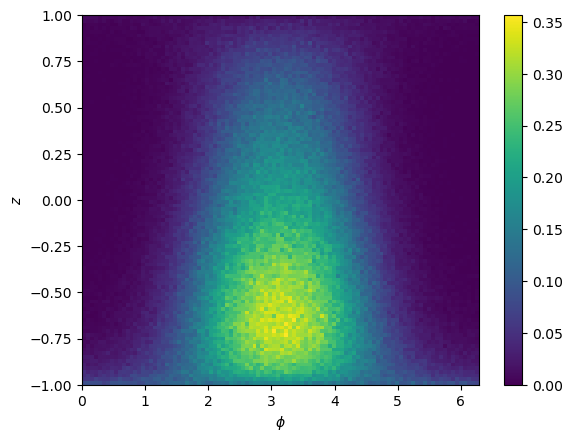

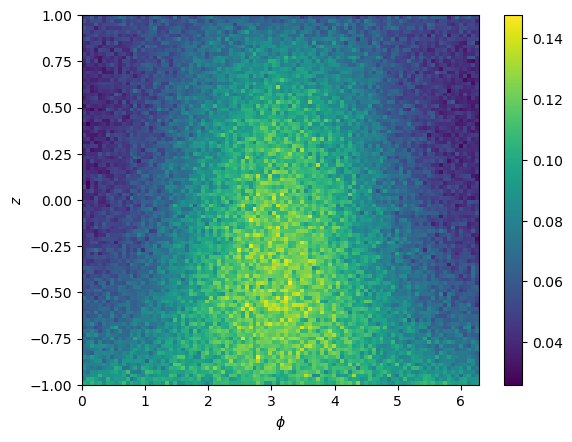

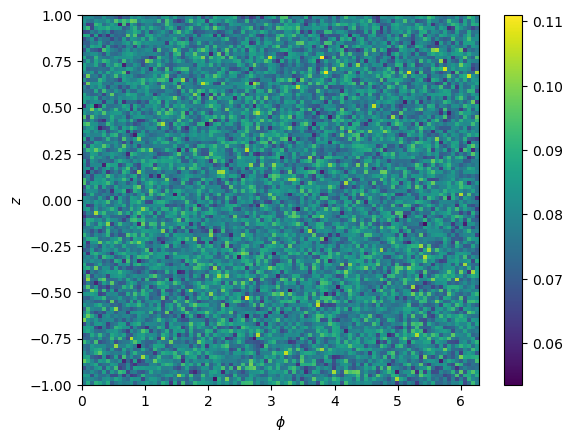

In [7]:
# Plotting diffused samples

for i in range(len(timesTau)-1):
    plotSphereHist(sphere.hk(samples0, timesTau[i+1]))

The sample at $t=4$ looks nearly uniform. How bad is the error if we approximate by uniform?

In [8]:
# Calculate TV distance between uniform and t=4 smiley

nZ = 1001
nPhi = 1000

phi = np.linspace(0, 2*np.pi, nPhi, endpoint=False)
z = np.linspace(-1, 1, nZ)[:, None]
sinTh = np.sqrt(1 - z**2)

vX = np.cos(phi)*sinTh
vY = np.sin(phi)*sinTh
vZ = np.broadcast_to(z, (nZ, nPhi))
v = np.stack([vX, vY, vZ], axis=-1) 

values = smileyDist(v, 4)

#Take absolute error from uniform dist 1/area. TV distance has an overall factor of 1/2
integrand = .5*np.abs(values-1/(4*np.pi))
integrandZ = 2*np.pi*integrand.mean(1)

#Trapezoidal rule
dz = 2/(nZ-1)
integral = dz*(.5*(integrandZ[0]+integrandZ[-1])+integrandZ[1:-1].sum())
print(f"TV distance from uniform at t=4 = {integral.item()}")

TV distance from uniform at t=4 = 0.00019461531468021066


## Solving ODE for reverse diffusion

Construct score field for smiley face distribution diffused to arbitrary $t$. Test forward Euler for various time stepping schemes, using TV distance as a diagnostic. It turns out linear time steps in log t does well. Then test an RK2 method on the sphere by Leung, Chau, Lee (2024).

### Euler integration of reverse diffusion ODE

In [9]:
#construct reverse times linear in the square root of t
nSteps = 100
du = 2/nSteps
reverseTimesLin = []
for i in range(0,nSteps+1):
    reverseTimesLin.append((2-i*du)**2)

In [10]:
#linear spacing in log t
nSteps = 100
reverseTimes = []
for i in range(nSteps + 1):
    a = i/nSteps
    tEff = np.exp((1-a)*np.log(t0 + 4) + a*np.log(t0))
    reverseTimes.append(tEff - t0)

In [13]:
#sample at t=4 from uniform
nBatch = 100000
samples4 = sphere.normalize(np.random.normal(0,1,(nBatch,3)))

In [ ]:
from tqdm.notebook import tqdm

samplesLin = samples4.copy()
for i in tqdm(range(len(reverseTimesLin)-1)):
    dt = reverseTimesLin[i]-reverseTimesLin[i+1]
    samplesLin = sde.eulerStep(samplesLin, reverseTimesLin[i], dt, scoreSmiley)

plotSphereHist(samplesLin)

In [ ]:
samples = samples4.copy()
for i in tqdm(range(len(reverseTimes)-1)):
    dt = reverseTimes[i]-reverseTimes[i+1]
    samples = sde.eulerStep(samples, reverseTimes[i], dt, scoreSmiley)

plotSphereHist(samples)

### Total variation (TV) distance of ODE results from initial distribution

In [21]:
nPhi = 100
print(f"TV distance of ODE, linear in tau timesteps")
print(f"nSteps: {nSteps},  nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samplesLin, nPhi))

TV distance of ODE, linear in tau timesteps
nSteps: 100,  nBatch: 100000,  nPhi: 100
0.10818310416207076


In [19]:
nPhi = 100
print(f"TV distance of ODE, linear in u timesteps")
print(f"nSteps: {nSteps},  nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samples, nPhi))

TV distance of ODE, linear in u timesteps
nSteps: 100,  nBatch: 100000,  nPhi: 100
0.08956794203209205


Compare the error of the ODE above with the error of a directly sampled distribution below

In [28]:
samples0 = smileySample(nBatch)
print(f"TV distance of histogram of direct samples")
print(f"nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samples0, nPhi))

TV distance of histogram of direct samples
nBatch: 100000,  nPhi: 100
0.07828160343195316


In [29]:
# A few more samples
samples0 = smileySample(nBatch)
print(distHist(samples0, nPhi))
samples0 = smileySample(nBatch)
print(distHist(samples0, nPhi))
samples0 = smileySample(nBatch)
print(distHist(samples0, nPhi))
samples0 = smileySample(nBatch)
print(distHist(samples0, nPhi))

0.08008092112191237
0.07997662043899605
0.08170480219140931
0.08195314829490224


### STVDRK2 method

An RK2 method on $S^2$ taken from Leung, Chau, Lee (2024). Basically Heun's method on $S^2$.

In [ ]:
#linear spacing in u, 50 time steps (2 score evaluations each)
nBatch = 100000
nSteps = 50
reverseTimes = []
for i in range(nSteps + 1):
    a = i/nSteps
    tEff = np.exp((1-a)*np.log(t0 + 4) + a*np.log(t0))
    reverseTimes.append(tEff - t0)

samplesRK2 = samples4.copy()
for i in tqdm(range(len(reverseTimes)-1)):
    dt = reverseTimes[i]-reverseTimes[i+1]
    samplesRK2 = sde.rk2Step(samplesRK2, reverseTimes[i], dt, scoreSmiley)

plotSphereHist(samplesRK2)

In [27]:
nPhi = 100
print(f"TV distance of ODE (RK2), linear in u timesteps")
print(f"nSteps: {nSteps},  nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samplesRK2, nPhi))

TV distance of ODE (RK2), linear in u timesteps
nSteps: 50,  nBatch: 100000,  nPhi: 100
0.08068209151048962


Within the range of the TV distance of the direct samples. Let's try going to larger nBatch.

In [ ]:
nBatch = 1000000
samples4 = sphere.normalize(np.random.normal(0,1,(nBatch,3)))

samplesRK2Large = samples4.copy()
for i in tqdm(range(len(reverseTimes)-1)):
    dt = reverseTimes[i]-reverseTimes[i+1]
    samplesRK2Large = sde.rk2Step(samplesRK2Large, reverseTimes[i], dt, scoreSmiley)

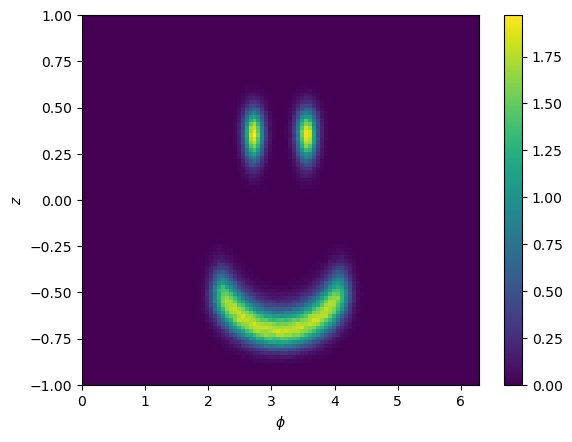

TV distance of ODE (RK2), linear in u timesteps
nSteps: 50,  nBatch: 1000000,  nPhi: 200
0.0438124543696091


In [34]:
plotSphereHist(samplesRK2Large)

nPhi = 200
print(f"TV distance of ODE (RK2), linear in u timesteps")
print(f"nSteps: {nSteps},  nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samplesRK2Large, nPhi))

TV distance is indistinguishable from direct samples:

In [30]:
nPhi = 200
nBatch = 1000000
samples0 = smileySample(nBatch)
print(f"TV distance of histogram of direct samples")
print(f"nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samples0, nPhi))

TV distance of histogram of direct samples
nBatch: 1000000,  nPhi: 200
0.04398168420499351


In [31]:
# A few more samples
samples0 = smileySample(nBatch)
print(distHist(samples0, nPhi))
samples0 = smileySample(nBatch)
print(distHist(samples0, nPhi))
samples0 = smileySample(nBatch)
print(distHist(samples0, nPhi))
samples0 = smileySample(nBatch)
print(distHist(samples0, nPhi))

0.0443219059778094
0.04416325843258872
0.043479989131646274
0.043344400258128093


## Euler-Maruyama and predictor/corrector schemes

#### Euler-Maruyama

  0%|          | 0/100 [00:00<?, ?it/s]

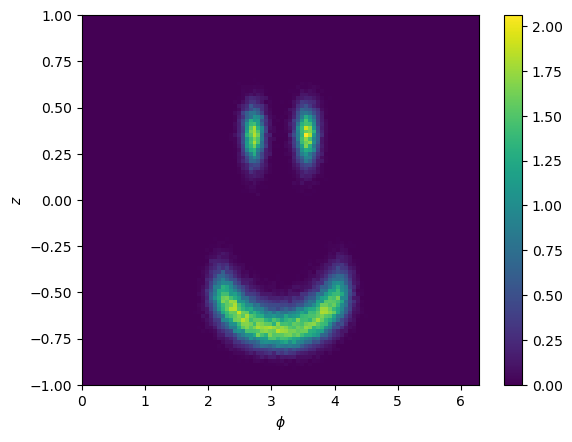

In [94]:
#linear spacing in u, 100 time steps (1 score evaluation each)
nBatch = 100000
nSteps = 100
reverseTimes = []
for i in range(nSteps + 1):
    a = i/nSteps
    tEff = np.exp((1-a)*np.log(t0 + 4) + a*np.log(t0))
    reverseTimes.append(tEff - t0)

samplesSDE = samples4.copy()
for i in tqdm(range(len(reverseTimes)-1)):
    dt = reverseTimes[i]-reverseTimes[i+1]
    samplesSDE = sde.eulerMaruyamaStep(samplesSDE, reverseTimes[i], dt, scoreSmiley)

plotSphereHist(samplesSDE)

In [96]:
nPhi = 200
print(f"TV distance of SDE, linear in u timesteps")
print(f"nSteps: {nSteps},  nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samplesSDE, nPhi))

TV distance of SDE, linear in u timesteps
nSteps: 100,  nBatch: 100000,  nPhi: 200
0.09512085682747819


#### Predictor-Corrector

In [104]:
importlib.reload(sde)

<module 'sde' from 'C:\\Users\\keita\\ml_projects\\O3slashCP1\\sde.py'>

  0%|          | 0/50 [00:00<?, ?it/s]

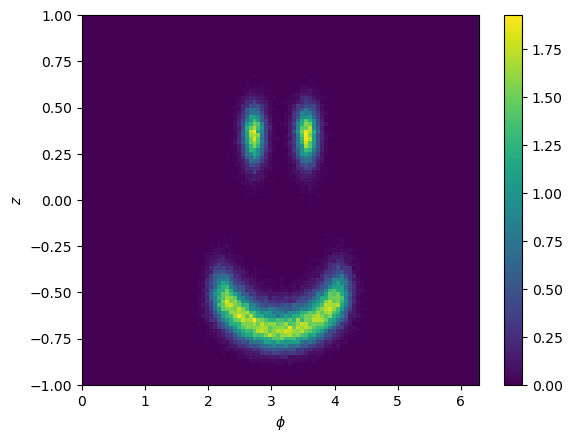

In [114]:
#linear spacing in u, 50 time steps (2 score evaluations each)
nSteps = 50
reverseTimes = []
for i in range(nSteps + 1):
    a = i/nSteps
    tEff = np.exp((1-a)*np.log(t0 + 4) + a*np.log(t0))
    reverseTimes.append(tEff - t0)

samplesPC = samples4.copy()
ds = .001
for i in tqdm(range(len(reverseTimes)-1)):
    dt = reverseTimes[i]-reverseTimes[i+1]
    samplesPC = sde.eulerMaruyamaStep(samplesPC, reverseTimes[i], dt, scoreSmiley)
    samplesPC = sde.langevinStep(samplesPC, reverseTimes[i+1], ds, scoreSmiley)

plotSphereHist(samplesPC)

In [113]:
nPhi = 200
print(f"TV distance of SDE, linear in u timesteps")
print(f"nSteps: {nSteps},  nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samplesPC, nPhi))

TV distance of SDE, linear in u timesteps
nSteps: 50,  nBatch: 100000,  nPhi: 200
0.0995372769819785


## Training a neural net

### Create and train new net

In [57]:
# Model and optimizer
smileyNet = MLP().to(device)
optimizer = torch.optim.Adam(
    smileyNet.parameters(),
    lr=5e-5,
    betas=(0.9, 0.999)
)

In [ ]:
lossHistory = trainSmiley(smileyNet, optimizer, sampleTraining, batchSize=400, nSteps=5001)

In [ ]:
lossHistory = trainSmiley(smileyNet, optimizer, sampleTraining, batchSize=1600, nSteps=5001)

In [ ]:
lossHistory = trainSmiley(smileyNet, optimizer, sampleTraining, batchSize=6400, nSteps=2001)

In [73]:
optimizer = torch.optim.Adam(
    smileyNet.parameters(),
    lr=5e-5,
    betas=(0.9, 0.999)
)

for i in range(5):
    print(f'minU = {1.0-0.2*(1+i)}, maxU = 1.0')
    lossHistory = trainSmiley(smileyNet, optimizer, sampleTraining, batchSize=25600, nSteps=1001, minU = 1.0-0.2*(1+i))

minU = 0.8, maxU = 1.0


  0%|          | 0/1001 [00:00<?, ?it/s]

step      0   loss 42.807271
step    100   loss 5.085843
step    200   loss 1.449489
step    300   loss 0.537777
step    400   loss 0.250805
step    500   loss 0.135095
step    600   loss 0.081535
step    700   loss 0.052428
step    800   loss 0.038145
step    900   loss 0.028803
step   1000   loss 0.023531
minU = 0.6, maxU = 1.0


  0%|          | 0/1001 [00:00<?, ?it/s]

step      0   loss 0.757256
step    100   loss 0.141171
step    200   loss 0.087333
step    300   loss 0.066583
step    400   loss 0.054679
step    500   loss 0.039557
step    600   loss 0.034557
step    700   loss 0.026624
step    800   loss 0.022810
step    900   loss 0.019095
step   1000   loss 0.016663
minU = 0.3999999999999999, maxU = 1.0


...

step      0   loss 0.356378
step    100   loss 0.063741
step    200   loss 0.046609
step    300   loss 0.029812
step    400   loss 0.026708
step    500   loss 0.018895
step    600   loss 0.021670
step    700   loss 0.020609
step    800   loss 0.016977
step    900   loss 0.014998
step   1000   loss 0.013778
minU = 0.19999999999999996, maxU = 1.0


  0%|          | 0/1001 [00:00<?, ?it/s]

step      0   loss 1.124026
step    100   loss 0.292014
step    200   loss 0.192153
step    300   loss 0.128996
step    400   loss 0.119795
step    500   loss 0.095844
step    600   loss 0.118687
step    700   loss 0.042871
step    800   loss 0.099695
step    900   loss 0.065419
step   1000   loss 0.060535
minU = 0.0, maxU = 1.0


  0%|          | 0/1001 [00:00<?, ?it/s]

step      0   loss 3.628775
step    100   loss 1.075068
step    200   loss 0.645565
step    300   loss 1.099179
step    400   loss 1.655609
step    500   loss 0.984875
step    600   loss 0.853029
step    700   loss 0.762831
step    800   loss -0.041325
step    900   loss 0.468116
step   1000   loss 0.633796


In [ ]:
# Incompletely trained model
torch.save(smileyNet.state_dict(), "smileyNet1.pt")

### Load and test trained net

In [36]:
# Load net trained with sampleTrainingDirect

import torch
from model import MLP
from sde import tauFromU, sigmaFromU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

smileyNetDirect = MLP().to(device)
smileyNetDirect.load_state_dict(torch.load("smileyNetDirect.pt"))

<All keys matched successfully>

#### Plot score distributions

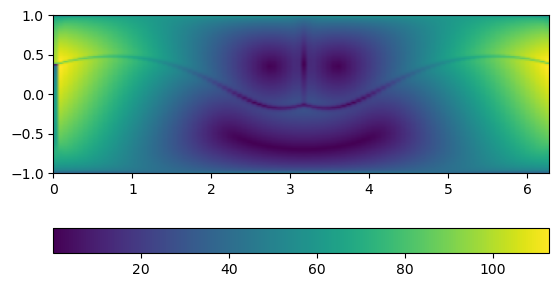

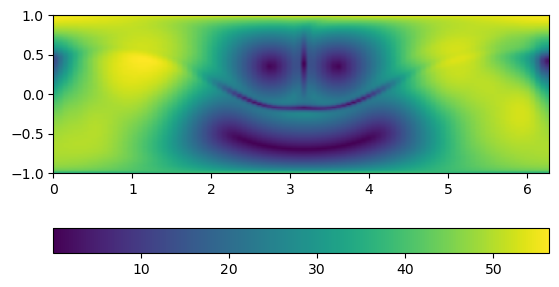

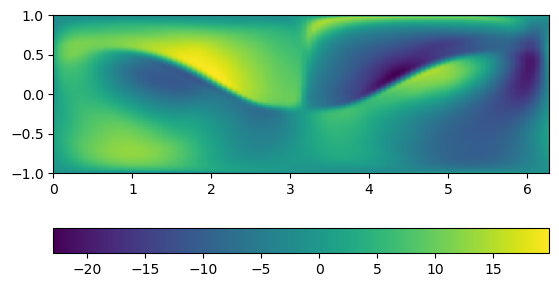

In [48]:
# Plot exact score norm field at low time

plotScoreNormExact(.1)

# Plot score norm field from neural net, along with gauge component

plotScoreNormNet(smileyNetDirect, .1, plotGauge = True)

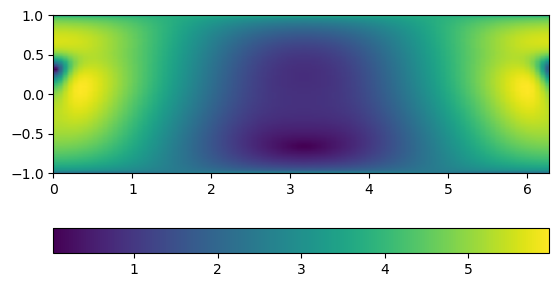

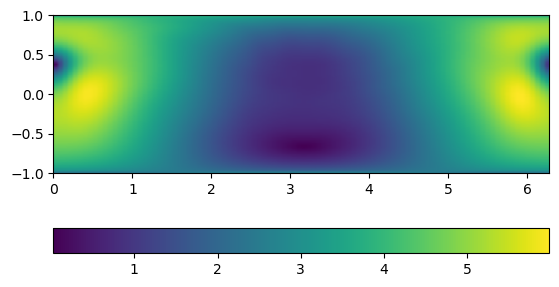

In [47]:
#Plot at intermediate time

plotScoreNormExact(.5)
plotScoreNormNet(smileyNetDirect, .5)

#### Test ODE

In [51]:
#sample at t=4 from uniform
nBatch = 100000
samples4 = sphere.normalize(np.random.normal(0,1,(nBatch,3)))

#linear spacing in log t
nSteps = 50
reverseTimes = []
for i in range(nSteps+1):
    a = i/nSteps
    tEff = np.exp((1-a)*np.log(t0 + 4) + a*np.log(t0))
    reverseTimes.append(tEff - t0)

  0%|          | 0/50 [00:00<?, ?it/s]

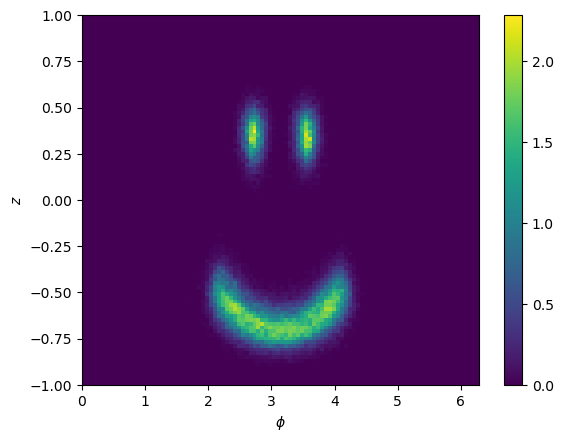

In [54]:
from tqdm.notebook import tqdm

samples = samples4.copy()
for i in tqdm(range(len(reverseTimes)-1)):
    dt = reverseTimes[i]-reverseTimes[i+1]
    samples = sde.rk2Step(samples, reverseTimes[i], dt, lambda x, t : score_np(x, t, smileyNetDirect))

plotSphereHist(samples)

In [55]:
nPhi = 100
print(f"TV distance of ODE (RK2), linear in u timesteps, from neural net trained on exact score")
print(f"nSteps: {nSteps},  nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samples, nPhi))

TV distance of ODE (RK2), linear in u timesteps, from neural net trained on exact score
nSteps: 50,  nBatch: 100000,  nPhi: 100
0.08824428129123739


### Test models trained with conditional score

#### Poor model

The output above is for a model trained against the exact score, not the conditional score depending on `x0` at the initial time. Earlier in this notebook we trained smileyNet on the conditional score for a small number of training steps (~12k at small batchSize and then 5k at batchSize = 25600). The smiley face is apparent but of poor quality.

  0%|          | 0/50 [00:00<?, ?it/s]

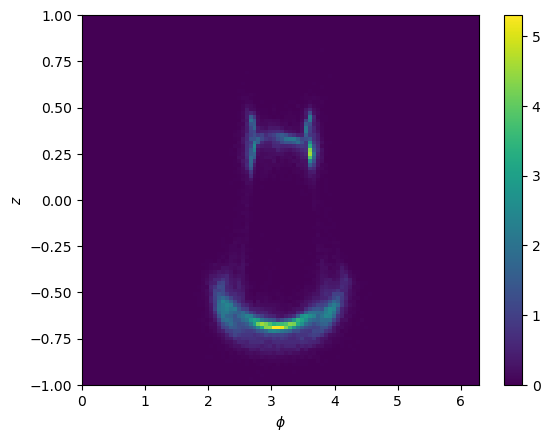

In [76]:
from tqdm.notebook import tqdm

samples = samples4.copy()
for i in tqdm(range(len(reverseTimes)-1)):
    dt = reverseTimes[i]-reverseTimes[i+1]
    samples = sde.rk2Step(samples, reverseTimes[i], dt, lambda x, t : score_np(x, t, smileyNet))

plotSphereHist(samples)

Can we do better with SDE methods?

  0%|          | 0/100 [00:00<?, ?it/s]

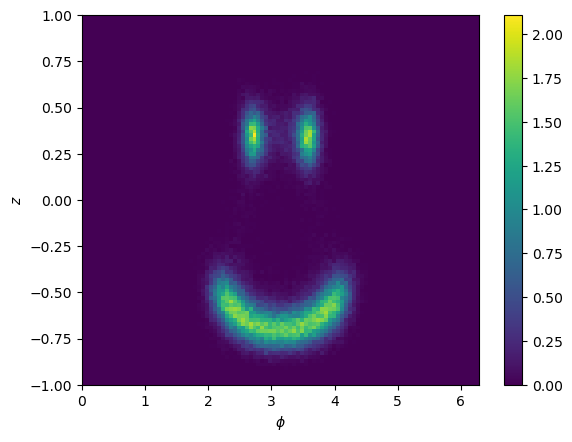

In [115]:
nSteps = 100
reverseTimes100 = []
for i in range(nSteps+1):
    a = i/nSteps
    tEff = np.exp((1-a)*np.log(t0 + 4) + a*np.log(t0))
    reverseTimes100.append(tEff - t0)

samples = samples4.copy()
for i in tqdm(range(len(reverseTimes100)-1)):
    dt = reverseTimes100[i]-reverseTimes100[i+1]
    samples = sde.eulerMaruyamaStep(samples, reverseTimes100[i], dt, lambda x, t : score_np(x, t, smileyNet))

plotSphereHist(samples)

In [116]:
nPhi = 100
print(f"TV distance of SDE, linear in u timesteps, from neural net trained on conditional score")
print(f"nSteps: {nSteps},  nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samples, nPhi))

TV distance of SDE, linear in u timesteps, from neural net trained on conditional score
nSteps: 100,  nBatch: 100000,  nPhi: 100
0.09635562083038977


#### Pre-trained model

The saved model `smileyNetDeprecated` was also trained on conditional score for greater number of training steps, but with a deprecated version of `sampleTraining` where the output is weighted by the standard deviation `sigma`.

In [80]:
# Load net trained with sampleTraining, but with output scaled by sigma

import torch
from model import MLP
from sde import tauFromU, sigmaFromU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

smileyNetDeprecated = MLP().to(device)
smileyNetDeprecated.load_state_dict(torch.load("smileyNet.pt"))

<All keys matched successfully>

In [81]:
# Build a wrapper class

class SigmaNormalizedNet(torch.nn.Module):
    def __init__(self, oldNet):
        super().__init__()
        self.oldNet = oldNet

    def forward(self, inp):
        # inp[..., :3] is x
        # inp[..., 3:] is u
        u = inp[..., 3:]

        F = self.oldNet(inp)

        sigma = torch.sqrt(
            2 * torch.tensor(t0, dtype=inp.dtype, device=inp.device)
            * ((1 + tF/t0)**u - 1)
        )

        return F / sigma

In [86]:
smileyNetNormalized = SigmaNormalizedNet(smileyNetDeprecated)
smileyNetNormalized.eval();

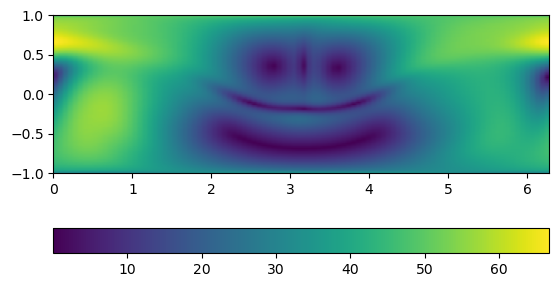

In [93]:
# plot score for low time
plotScoreNormNet(smileyNetNormalized, .1)

  0%|          | 0/49 [00:00<?, ?it/s]

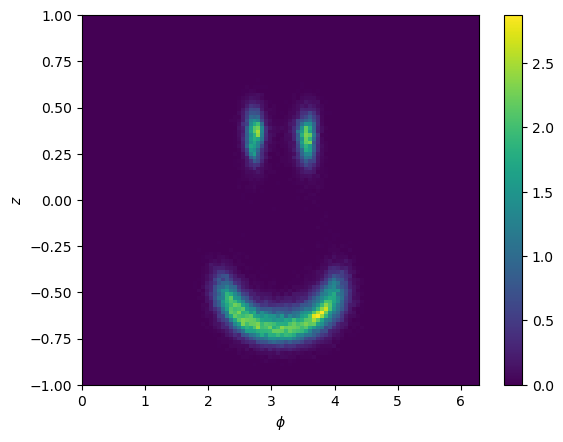

In [89]:
# ODE results, omitting last step (due to issues with sigma)

from tqdm.notebook import tqdm

samples = samples4.copy()
for i in tqdm(range(len(reverseTimes)-2)):
    dt = reverseTimes[i]-reverseTimes[i+1]
    samples = sde.rk2Step(samples, reverseTimes[i], dt, lambda x, t : score_np(x, t, smileyNetNormalized))

plotSphereHist(samples)

In [91]:
nPhi = 100
print(f"TV distance of ODE (RK2), linear in u timesteps, from neural net trained on conditional score")
print(f"nSteps: {nSteps}-1,  nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samples, nPhi))

TV distance of ODE (RK2), linear in u timesteps, from neural net trained on conditional score
nSteps: 50-1,  nBatch: 100000,  nPhi: 100
0.1183374649808978


Try Euler-Maruyama for this one too

  0%|          | 0/100 [00:00<?, ?it/s]

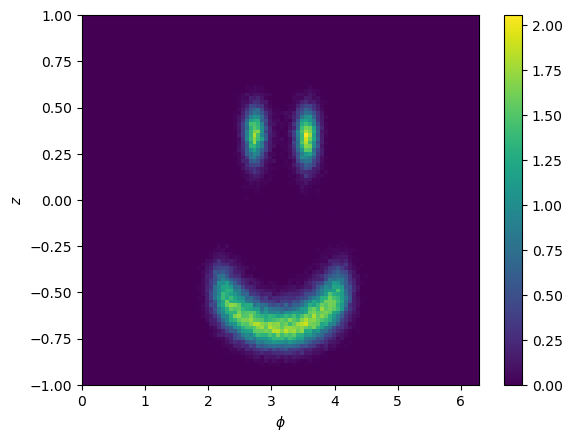

In [119]:
samples = samples4.copy()
for i in tqdm(range(len(reverseTimes100)-1)):
    dt = reverseTimes100[i]-reverseTimes100[i+1]
    samples = sde.eulerMaruyamaStep(samples, reverseTimes100[i], dt, lambda x, t : score_np(x, t, smileyNetNormalized))

plotSphereHist(samples)

In [118]:
nPhi = 100
print(f"TV distance of SDE, linear in u timesteps, from neural net trained on conditional score")
print(f"nSteps: {nSteps},  nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samples, nPhi))

TV distance of SDE, linear in u timesteps, from neural net trained on conditional score
nSteps: 100,  nBatch: 100000,  nPhi: 100
0.07873075860988282


In [120]:
# Another sample
print(distHist(samples, nPhi))

0.07832017182920059
